In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import datetime
from dateutil.relativedelta import relativedelta

In [2]:
repatriations = pd.read_excel("KHSM Repatriations fy25m11.xlsx", sheet_name=None)

Our repatriation data contains many datasets with varying levels of detail on the repatriations. We will be working mainly with the datasets that contain some sort of monthly information.

In [3]:
repatriations.keys()

dict_keys(['Annual Repatriations', 'Monthly Repatriations', 'Annual Repatriation Type', 'Monthly Repatriation Type', 'Annual Criminal', 'Monthly Criminal', 'Annual Arrest Location', 'Monthly Arrest Location', 'Annual Citizenship', 'Monthly Citizenship', 'Annual Repatriation Agency', 'Monthly Repatriation Agency', 'Annual Type & Dtl Type', 'Monthly Type & Dtl Type', 'Annual Type & Criminal', 'Monthly Type & Criminal', 'Annual Type & Arrest Loc', 'Monthly Type & Arr Loc', 'Annual Type & Citp', 'Monthly Type & Citp', 'Annual Typ & Rep Agency', 'Monthly Typ & Rep Agency'])

For our encounters data, we need to merge two datasets: the first covers 2020-2023, which we will only use for the years 2020-2022, and the second covers 2023-2026:

In [4]:
encounters2023 = pd.read_csv("nationwide-encounters-fy20-fy23-aor.csv")
encounters2022 = encounters2023[encounters2023["Fiscal Year"] != 2023]
encounters2326 = pd.read_csv("nationwide-encounters-fy23-fy26-jan-aor.csv")
encounters2326["Fiscal Year"].unique()

array(['2023', '2024', '2025', '2026 (FYTD)'], dtype=object)

We will need to convert the "Fiscal Year" column in the second dataset to type int since it is currently a string:

In [5]:
encounters2326["Fiscal Year"] = encounters2326["Fiscal Year"].apply(lambda x: int(2026) if ("2026" in x) else int(x))

In [6]:
encounters = pd.concat([encounters2022,  encounters2326], axis=0)

In [7]:
encounters.info()

<class 'pandas.core.frame.DataFrame'>
Index: 83920 entries, 0 to 46582
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Fiscal Year             83920 non-null  int64 
 1   Month Grouping          83920 non-null  object
 2   Month (abbv)            83920 non-null  object
 3   Component               83920 non-null  object
 4   Land Border Region      83920 non-null  object
 5   Area of Responsibility  83920 non-null  object
 6   AOR (Abbv)              83920 non-null  object
 7   Demographic             83920 non-null  object
 8   Citizenship             83920 non-null  object
 9   Title of Authority      83920 non-null  object
 10  Encounter Type          83920 non-null  object
 11  Encounter Count         83920 non-null  int64 
dtypes: int64(2), object(10)
memory usage: 8.3+ MB


We will rename the encounters columns "Month (abbv)" and "Fiscal Year" to "Month" and "Year" for easier converting to datetime:

In [8]:
encounters.rename(columns={"Month (abbv)":"Month", "Fiscal Year":"Year"}, inplace=True)

In [9]:
encounters["Month"].unique()

array(['APR', 'AUG', 'DEC', 'FEB', 'JAN', 'JUL', 'JUN', 'MAR', 'MAY',
       'NOV', 'OCT', 'SEP'], dtype=object)

In [10]:
repatriations["Monthly Repatriations"]["Month"].unique()

array(['01 October', '02 November', '03 December', '04 January',
       '05 February', '06 March', '07 April', '08 May', '09 June',
       '10 July', '11 August', '12 September'], dtype=object)

We will change the encounters "Month" column to match the value represented in the "Month" column of the monthly repatriations data for easier merging later on. We also only want to keep the numeric value and ignore the rest of the string, so we will trim the value after the first two characters and convert it to an int:

In [11]:
encounters["Month"] = encounters["Month"].apply((lambda x: int(next(m for m in repatriations["Monthly Repatriations"]["Month"].unique() if x.lower() in m.lower())[:2])))

We will create a new column called "Date" that is a datetime created from the "Month" and "Year" column. Since this date is written in fiscal year, we will subtract three months from it so that it is the actual date. In case we need to keep the date in its fiscal year formatting, we will also create a new column called "Fiscal Date" that is a datetime created from the "Month" and "Year" column.

In [12]:
encounters["Date"] = pd.to_datetime(encounters[['Year', 'Month']].assign(DAY=1)).apply(lambda x: x - relativedelta(months=3))

For all monthly data in the repatriations data, we only want to keep the numeric value in the "Month" column and ignore the rest of the string, so we will trim the value after the first two characters and convert it to an int. We will create a new column called "Date" that is a datetime created from the "Month" and "Year" column. Since this date is written in fiscal year, we will subtract three months from it so that it is the actual date. In case we need to keep the date in its fiscal year formatting, we will also create a new column called "Fiscal Date" that is a datetime created from the "Month" and "Year" column:

In [13]:
for key in repatriations.keys():
    if "monthly" in key.lower():
        repatriations[key]["Month"] =  repatriations[key]["Month"].apply(lambda x: int(x[:2]))
        repatriations[key].rename(columns={"Fiscal\nYear":"Year"}, inplace=True)
        repatriations[key]["Date"] = pd.to_datetime(repatriations[key][['Year', 'Month']].assign(DAY=1)).apply(lambda x: x - relativedelta(months=3))

We want to create a dataset that contains the number of monthly repatriations and encounters, as well as the ratio of monthly repatrations to encounters.

We can get the number of monthly repatriations from the repatriations data:

In [14]:
monthly_repatriations = repatriations["Monthly Repatriations"]

In [15]:
monthly_repatriations.columns

Index(['Year', 'Month', 'Quantity', 'Date'], dtype='object')

We need to group our encounter data by "Date" and sum the "Encounter Count" column to get the number of monthly encounters:

In [16]:
monthly_encounters = encounters.groupby("Date")["Encounter Count"].sum()
monthly_encounters = monthly_encounters.reset_index()

Now that we have the monthly repatriations and encounters, we can create a new dataframe, merging on "Date":

In [17]:
repats_encounters = pd.merge(monthly_repatriations, monthly_encounters, on="Date")

Next, we can create our "Ratio" column that contains the ratio of monthly repatriations to encounters:

In [18]:
repats_encounters["Ratio"] = repats_encounters["Quantity"]/repats_encounters["Encounter Count"]

We now have a dataset that contains the number of repatriations ("Quantity"), encounters ("Encounter Counts"), and ratio of repatriations to encounters ("Ratio") for a given month and year ("Date"):

In [19]:
repats_encounters.head()

,Year,Month,Quantity,Date,Encounter Count,Ratio
0,2020,1,51360,2019-10-01,61159,0.839778
1,2020,2,46120,2019-11-01,57524,0.801752
2,2020,3,44920,2019-12-01,56186,0.799487
3,2020,4,47060,2020-01-01,52254,0.900601
4,2020,5,48730,2020-02-01,54884,0.887873


In [20]:
monthly_repatriations.Year.unique()

array([2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020,
       2021, 2022, 2023, 2024, 2025])

Importing the policy markers dataset and renaming its "month" column that actually contains month and year to "Date" and changing its type to datetime for easier merging.

In [21]:
policy_markers = pd.read_csv("policy_markers_monthly_2015_2025.csv")
policy_markers.rename(columns={"month" : "Date"}, inplace=True)
policy_markers["Date"] = pd.to_datetime(policy_markers["Date"])
policy_markers.head()

,Date,admin,phe_covid,title42,border_national_emergency,mpp_active,clp_rule_active,mayorkas_priorities_active,title42_uac_exempt
0,2015-01-01,Obama,0,0,0,0,0,0,0
1,2015-02-01,Obama,0,0,0,0,0,0,0
2,2015-03-01,Obama,0,0,0,0,0,0,0
3,2015-04-01,Obama,0,0,0,0,0,0,0
4,2015-05-01,Obama,0,0,0,0,0,0,0


Below is a dataset that contains the number of repatriations ("Repatriations"), encounters ("Encounters"), ratio of repatriations to encounters ("Ratio), and the administration and polices in place for a given month and year ("Date").

In [22]:
policies_repats_encounters = pd.merge(repats_encounters, policy_markers, on="Date")
policies_repats_encounters["Trump"] = policies_repats_encounters["admin"].apply(lambda x: 1 if x == "Trump" else 0)
policies_repats_encounters.rename(columns={"Year": "Fiscal Year", "Month": "Fiscal Month", "Encounter Count": "Encounters", "Quantity": "Repatriations"}, inplace=True)
policies_repats_encounters.head()

,Fiscal Year,Fiscal Month,Repatriations,Date,Encounters,Ratio,admin,phe_covid,title42,border_national_emergency,mpp_active,clp_rule_active,mayorkas_priorities_active,title42_uac_exempt,Trump
0,2020,1,51360,2019-10-01,61159,0.839778,Trump,0,0,1,1,0,0,0,1
1,2020,2,46120,2019-11-01,57524,0.801752,Trump,0,0,1,1,0,0,0,1
2,2020,3,44920,2019-12-01,56186,0.799487,Trump,0,0,1,1,0,0,0,1
3,2020,4,47060,2020-01-01,52254,0.900601,Trump,0,0,1,1,0,0,0,1
4,2020,5,48730,2020-02-01,54884,0.887873,Trump,1,0,1,1,0,0,0,1


Text(0, 0.5, 'Ratio')

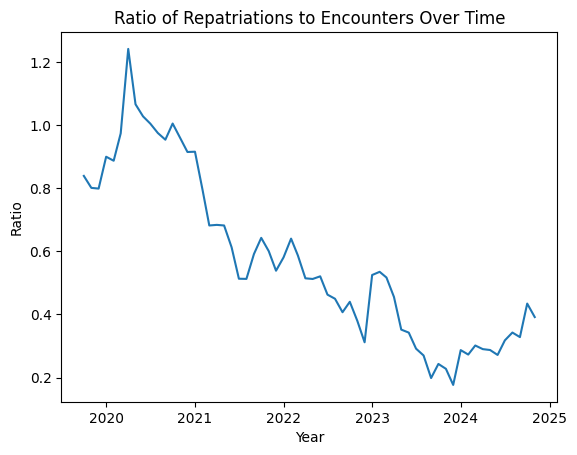

In [23]:
fig, ax = plt.subplots()
ax.plot(policies_repats_encounters["Date"], policies_repats_encounters["Ratio"])
ax.set_title("Ratio of Repatriations to Encounters Over Time")
ax.set_xlabel("Year")
ax.set_ylabel("Ratio")

Text(0, 0.5, 'Ratio')

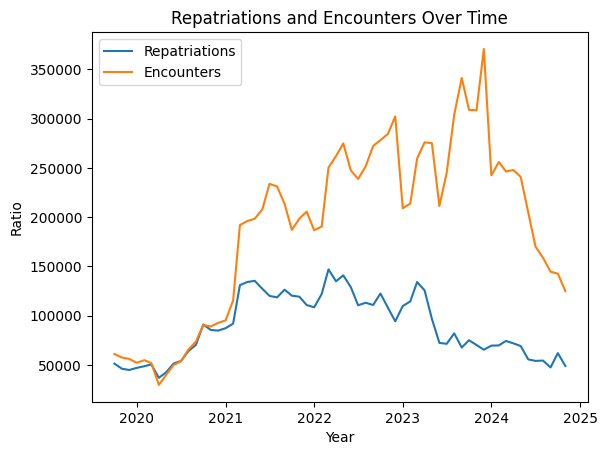

In [24]:
fig, ax = plt.subplots()
ax.plot(policies_repats_encounters["Date"], policies_repats_encounters["Repatriations"], label="Repatriations")
ax.plot(policies_repats_encounters["Date"], policies_repats_encounters["Encounters"], label="Encounters")
ax.legend()
ax.set_title("Repatriations and Encounters Over Time")
ax.set_xlabel("Year")
ax.set_ylabel("Ratio")